# Vanilla Rate RNN for Dynamic Foraging Task

## Imports

In [19]:
import os
import random
from pathlib import Path
import sys

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Add repo/src to sys.path so rnn_utils and data_io are importable.
# Works whether Jupyter is started from the repo root or from notebooks/.
try:
    _nb_dir = Path(__file__).resolve().parent
except NameError:
    _nb_dir = Path.cwd()

for _candidate in [_nb_dir, _nb_dir.parent]:
    _src = _candidate / "src"
    if _src.exists():
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break

from rnn_utils import (
    TaskConfig,
    TwoArmedBanditBlockTask,
    VanillaRateRNN,
    VanillaRateRNNNeural,
    sample_training_batch,
    moving_average,
    train_model,
    train_on_real_session,
    train_neural_rnn,
    create_neural_targets_from_psth,
    align_behavior_and_neural,
    run_closed_loop_session_for_plot,
    plot_block_choice_panel,
    plot_pright_animal_vs_model,
    compute_unit_r2,
    plot_unit_trial_psth_overlays,
    visualize_neural_predictions,
)

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)

Using device: mps


## Train RNN to do task

In [20]:
task_cfg = TaskConfig(
    min_block_len=15,
    max_block_len=20,
    p_high=1.0,
    p_low=0.0,
    total_trials=180,
)
task = TwoArmedBanditBlockTask(task_cfg)

model = VanillaRateRNN(input_size=4, hidden_size=100, output_size=2, dt=1.0, tau=10.0, g=1.2).to(DEVICE)
loss_hist, acc_hist = train_model(
    model,
    task,
    steps=250,
    batch_size=128,
    lr=1e-3,
    grad_clip=2.0,
    print_every=20,
    device=DEVICE,
)


step   20 | loss 0.6828 | acc 0.564
step   40 | loss 0.6753 | acc 0.549
step   60 | loss 0.6686 | acc 0.547
step   80 | loss 0.6565 | acc 0.622
step  100 | loss 0.6391 | acc 0.585
step  120 | loss 0.6096 | acc 0.629
step  140 | loss 0.5782 | acc 0.632
step  160 | loss 0.5331 | acc 0.698
step  180 | loss 0.4064 | acc 0.820
step  200 | loss 0.3858 | acc 0.835
step  220 | loss 0.4086 | acc 0.817
step  240 | loss 0.3828 | acc 0.830


### Plot loss and accuracy

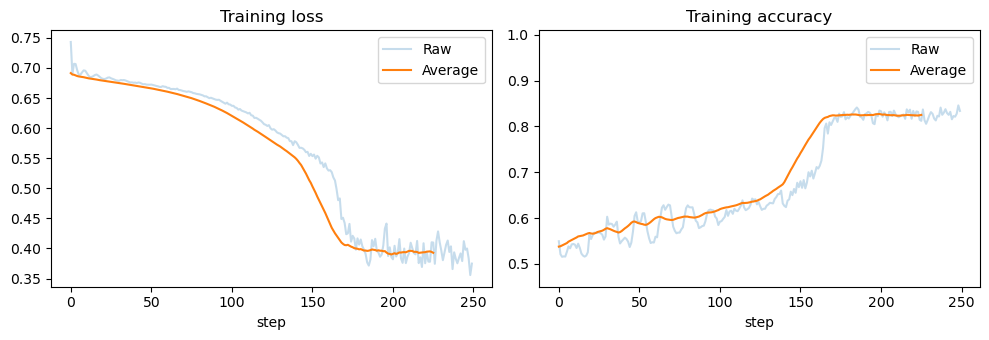

In [21]:

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(loss_hist, alpha=0.25, label="Raw")
axes[0].plot(moving_average(loss_hist, 25), label="Average")
axes[0].set_title("Training loss")
axes[0].set_xlabel("step")
axes[0].legend()

axes[1].plot(acc_hist, alpha=0.25, label="Raw")
axes[1].plot(moving_average(acc_hist, 25), label="Average")
axes[1].set_title("Training accuracy")
axes[1].set_xlabel("step")
axes[1].set_ylim(0.45, 1.01)
axes[1].legend()
plt.tight_layout()
plt.show()

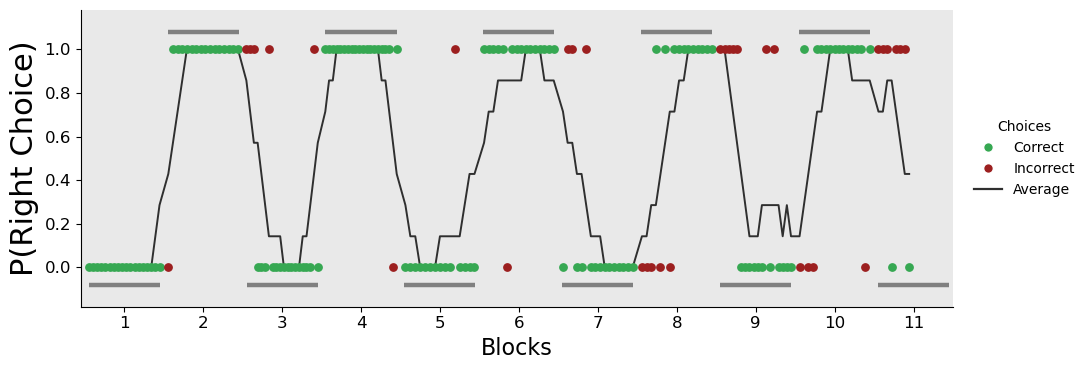

In [22]:
session_for_plot = run_closed_loop_session_for_plot(
    model,
    task,
    seed=12,
    temperature=0.5,
    epsilon=0.1,
    device=DEVICE,
)
plot_block_choice_panel(session_for_plot, smooth_window=7)

# Train Vanilla RNN to replicate animal behavior data

### Load animal data

In [23]:
import pandas as pd

# DATA_ROOT is the top-level directory that contains <animal>/<session>/ folders.
# Set the DATA_ROOT environment variable when running on a remote machine (e.g. GCP).
DATA_ROOT = Path(os.environ.get("DATA_ROOT", "/Users/lsye/DynamicForagingNPanalysis/data"))

from data_io import vectorize_labels

ANIMAL = "MM012"
SESSION = "20231211_172819"
SESSION_DIR = DATA_ROOT / ANIMAL / SESSION
TRIALDATA_PATH = SESSION_DIR / "trialdata.csv"

trialdata = pd.read_csv(TRIALDATA_PATH)
session_data = {"MFblocks": [], "MBblocks": []}  # not required for choice/history vectors

# Build the 4 model inputs used in this notebook:
# [prev_action_left, prev_action_right, prev_reward, trial_start]
prev_action_left = vectorize_labels(trialdata, session_data, "prev_choice_left", rewarded_only=False)
prev_action_right = vectorize_labels(trialdata, session_data, "prev_choice_right", rewarded_only=False)
prev_reward = vectorize_labels(trialdata, session_data, "prev_reward", rewarded_only=False)
trial_start = vectorize_labels(trialdata, session_data, "trial_start", rewarded_only=False)

# Target: observed animal choice (left=0, right=1)
y_real = vectorize_labels(trialdata, session_data, "choice", rewarded_only=False).astype(np.int64)

X_real = np.column_stack([
    prev_action_left,
    prev_action_right,
    prev_reward,
    trial_start,
]).astype(np.float32)

assert X_real.shape[0] == y_real.shape[0], "Input/target lengths must match."

# Single-session tensor shape for RNN: [batch=1, time, features]
X_real_torch = torch.tensor(X_real, dtype=torch.float32, device=DEVICE).unsqueeze(0)
y_real_torch = torch.tensor(y_real, dtype=torch.long, device=DEVICE).unsqueeze(0)

print(f"Loaded session: {ANIMAL}/{SESSION}")
print("X_real_torch shape:", tuple(X_real_torch.shape))
print("y_real_torch shape:", tuple(y_real_torch.shape))
print("Right-choice fraction:", y_real.mean().round(3))

Loaded session: MM012/20231211_172819
X_real_torch shape: (1, 337, 4)
y_real_torch shape: (1, 337)
Right-choice fraction: 0.531


### Train network

In [24]:
# Initialize a model
animal_model = VanillaRateRNN(
    input_size=X_real_torch.shape[-1],
    hidden_size=128,
    output_size=2,
    dt=1.0,
    tau=10.0,
    g=1.2,
).to(DEVICE)

animal_optimizer = torch.optim.Adam(animal_model.parameters(), lr=1e-3)
real_loss_hist, real_acc_hist = train_on_real_session(
    animal_model,
    X_real_torch,
    y_real_torch,
    epochs=600,
    lr=7e-4,
    grad_clip=1.5,
    print_every=50,
)

with torch.no_grad():
    animal_model.eval()
    logits_real, _ = animal_model(X_real_torch)
    probs_real = torch.softmax(logits_real, dim=-1)[0].detach().cpu().numpy()
    y_model_pred = np.argmax(probs_real, axis=1).astype(np.int64)

session_fit_acc = (y_model_pred == y_real).mean()
print(f"Final fit accuracy on session: {session_fit_acc:.3f}")


epoch   50 | loss 0.3814 | acc 0.834
epoch  100 | loss 0.3219 | acc 0.855
epoch  150 | loss 0.2961 | acc 0.858
epoch  200 | loss 0.2762 | acc 0.896
epoch  250 | loss 0.2619 | acc 0.899
epoch  300 | loss 0.2518 | acc 0.902
epoch  350 | loss 0.2417 | acc 0.905
epoch  400 | loss 0.2339 | acc 0.899
epoch  450 | loss 0.2290 | acc 0.908
epoch  500 | loss 0.2198 | acc 0.914
epoch  550 | loss 0.2128 | acc 0.911
epoch  600 | loss 0.2055 | acc 0.914
Final fit accuracy on session: 0.914


### Plot Loss and accuracy

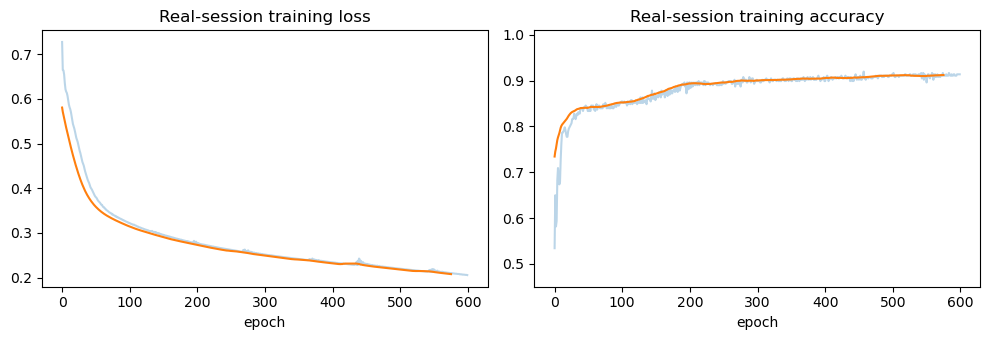

In [25]:

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(real_loss_hist, alpha=0.3)
axes[0].plot(moving_average(real_loss_hist, 25))
axes[0].set_title("Real-session training loss")
axes[0].set_xlabel("epoch")

axes[1].plot(real_acc_hist, alpha=0.3)
axes[1].plot(moving_average(real_acc_hist, 25))
axes[1].set_title("Real-session training accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylim(0.45, 1.01)

plt.tight_layout()
plt.show()

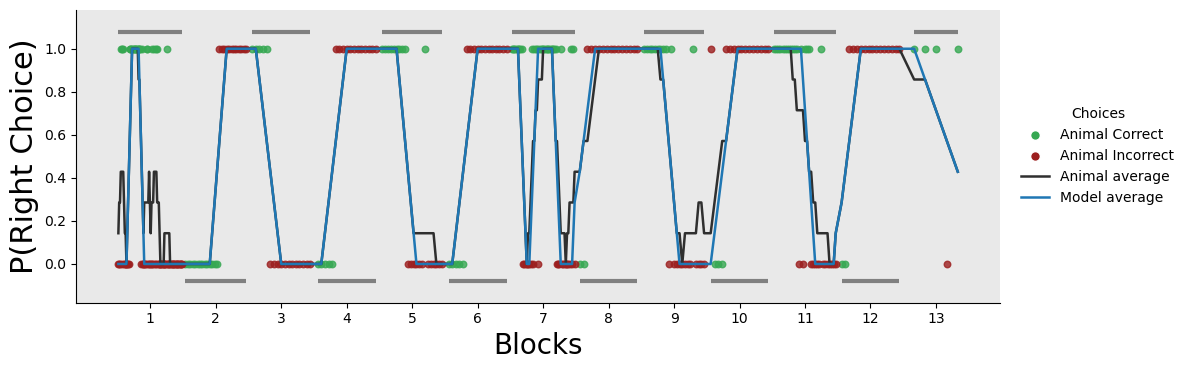

In [26]:
plot_pright_animal_vs_model(trialdata, y_real, y_model_pred, smooth_window=7, mode="overlay")

## Neural Activity Prediction RNN

Use behavior + other regressors to predict binned PSTH activity.

### Train network

In [27]:
# create regressor matrix

# Match df_dm.ipynb: pres=1, posts=2 -> window -1 to +2 s around choice (30 bins at 100ms)
neural_targets_dict, neural_meta = create_neural_targets_from_psth(
    animal_name=ANIMAL,
    session=SESSION,
    data_root=str(DATA_ROOT),
    trial_period="choice",
    rewarded_only=False,
    probes=("imec0", "imec1"),
    binwidth_ms=100,
    tpre=1,
    tpost=2,
)

TARGET_KEY = next(iter(neural_targets_dict))
print("Available targets:", list(neural_targets_dict.keys()))
print("Using:", TARGET_KEY, "| shape:", neural_targets_dict[TARGET_KEY].shape)


Available targets: ['imec0_ACC', 'imec0_DMS', 'imec1_M2', 'imec1_DLS']
Using: imec0_ACC | shape: (337, 3030)


In [28]:
# Load behavioral regressor matrix from dmat-early.npz (structure matches df_dm.ipynb)
# df_dm: BWMS=10 (10ms bins), pres=1, posts=2 -> 299 bins/trial, window -1 to +2 s
# dmat rows: trial-major, bins within trial (C-order). 100464 = 336 trials * 299 bins
# Early session 20231211_172819 -> dmat-early.npz; late 20231225_123125 -> dmat-late.npz
_repo = Path.cwd()
for _c in [Path.cwd(), Path.cwd().parent]:
    if (_c / "data" / "dmat-early.npz").exists():
        _repo = _c
        break
DMAT_PATH = _repo / "data" / "dmat-early.npz"

dmat_data = np.load(DMAT_PATH)
X_dmat = dmat_data["X"].astype(np.float32)  # (n_rows, n_regressors)

n_rows, n_regressors = X_dmat.shape
# df_dm: 10ms bins, pres=1, posts=2 -> 299 bins/trial = full -1 to +2 s choice window
# 100464 = 336 trials * 299 bins
n_bins_per_trial = 299
n_trials_dmat = n_rows // n_bins_per_trial
n_bins_total = n_trials_dmat * n_bins_per_trial
X_dmat_reshaped = X_dmat[:n_bins_total].reshape(n_trials_dmat, n_bins_per_trial, n_regressors)
# Average over full choice window (all 299 bins = -1 to +2 s) -> one regressor vector per trial
X_neural_behavior = X_dmat_reshaped.mean(axis=1).astype(np.float32)

# Keep alignment with selected neural target (trim to min trial count)
X_neural, Y_neural = align_behavior_and_neural(X_neural_behavior, neural_targets_dict[TARGET_KEY])

X_neural_torch = torch.tensor(X_neural, dtype=torch.float32, device=DEVICE).unsqueeze(0)
Y_neural_torch = torch.tensor(Y_neural, dtype=torch.float32, device=DEVICE).unsqueeze(0)

# Reinitialize model to match new input dimensionality.
neural_model = VanillaRateRNNNeural(
    input_size=X_neural_torch.shape[-1],
    hidden_size=128,
    output_size=Y_neural_torch.shape[-1],
    dt=1.0,
    tau=10.0,
    g=1.2,
).to(DEVICE)

print("Regressors from dmat-early.npz:", n_regressors, "features,", X_neural.shape[0], "trials")
print("X_neural_torch shape:", tuple(X_neural_torch.shape))
print("Y_neural_torch shape:", tuple(Y_neural_torch.shape))
print("Neural model input_size:", neural_model.input_size)

Regressors from dmat-early.npz: 184 features, 336 trials
X_neural_torch shape: (1, 336, 184)
Y_neural_torch shape: (1, 336, 3030)
Neural model input_size: 184


In [29]:
neural_loss_hist, neural_ve_hist = train_neural_rnn(
    neural_model,
    X_neural_torch,
    Y_neural_torch,
    epochs=500,
    lr=1e-3,
    grad_clip=2.0,
    print_every=10,
)



epoch   10 | mse 179.877548 | var_explained -0.142
epoch   20 | mse 170.731216 | var_explained -0.084
epoch   30 | mse 144.568314 | var_explained 0.082
epoch   40 | mse 129.154633 | var_explained 0.180
epoch   50 | mse 116.885124 | var_explained 0.258
epoch   60 | mse 109.750107 | var_explained 0.303
epoch   70 | mse 105.835991 | var_explained 0.328
epoch   80 | mse 103.038185 | var_explained 0.346
epoch   90 | mse 100.931953 | var_explained 0.359
epoch  100 | mse 99.050293 | var_explained 0.371
epoch  110 | mse 97.539635 | var_explained 0.381
epoch  120 | mse 96.148331 | var_explained 0.390
epoch  130 | mse 94.813225 | var_explained 0.398
epoch  140 | mse 93.565239 | var_explained 0.406
epoch  150 | mse 92.600304 | var_explained 0.412
epoch  160 | mse 91.647568 | var_explained 0.418
epoch  170 | mse 90.815056 | var_explained 0.424
epoch  180 | mse 90.044662 | var_explained 0.428
epoch  190 | mse 89.204498 | var_explained 0.434
epoch  200 | mse 88.326920 | var_explained 0.439
epoch  21

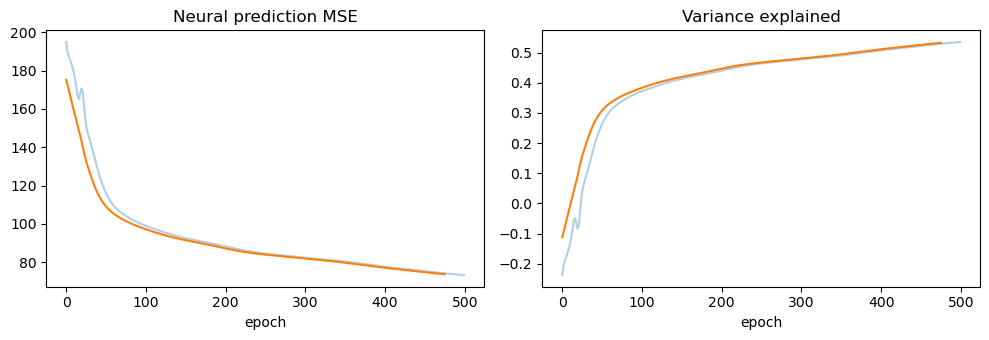

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(neural_loss_hist, alpha=0.35)
axes[0].plot(moving_average(neural_loss_hist, 25))
axes[0].set_title("Neural prediction MSE")
axes[0].set_xlabel("epoch")

axes[1].plot(neural_ve_hist, alpha=0.35)
axes[1].plot(moving_average(neural_ve_hist, 25))
axes[1].set_title("Variance explained")
axes[1].set_xlabel("epoch")

plt.tight_layout()
plt.show()

## Plot results

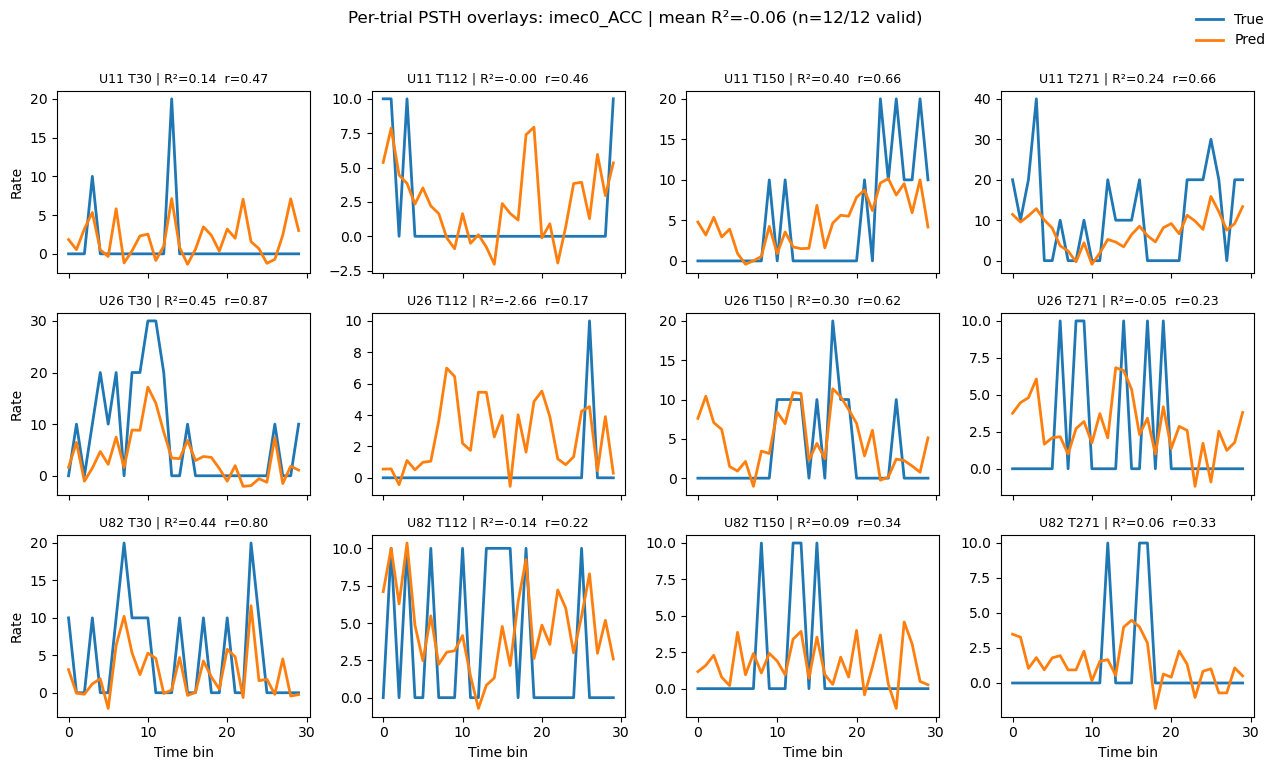

In [31]:
# plot_unit_trial_psth_overlays – imported from rnn_utils

plot_unit_trial_psth_overlays(
    neural_model,
    X_neural_torch,
    Y_neural_torch,
    neural_meta,
    TARGET_KEY,
    n_units=3,
    n_trials=4,
    seed=2,
)

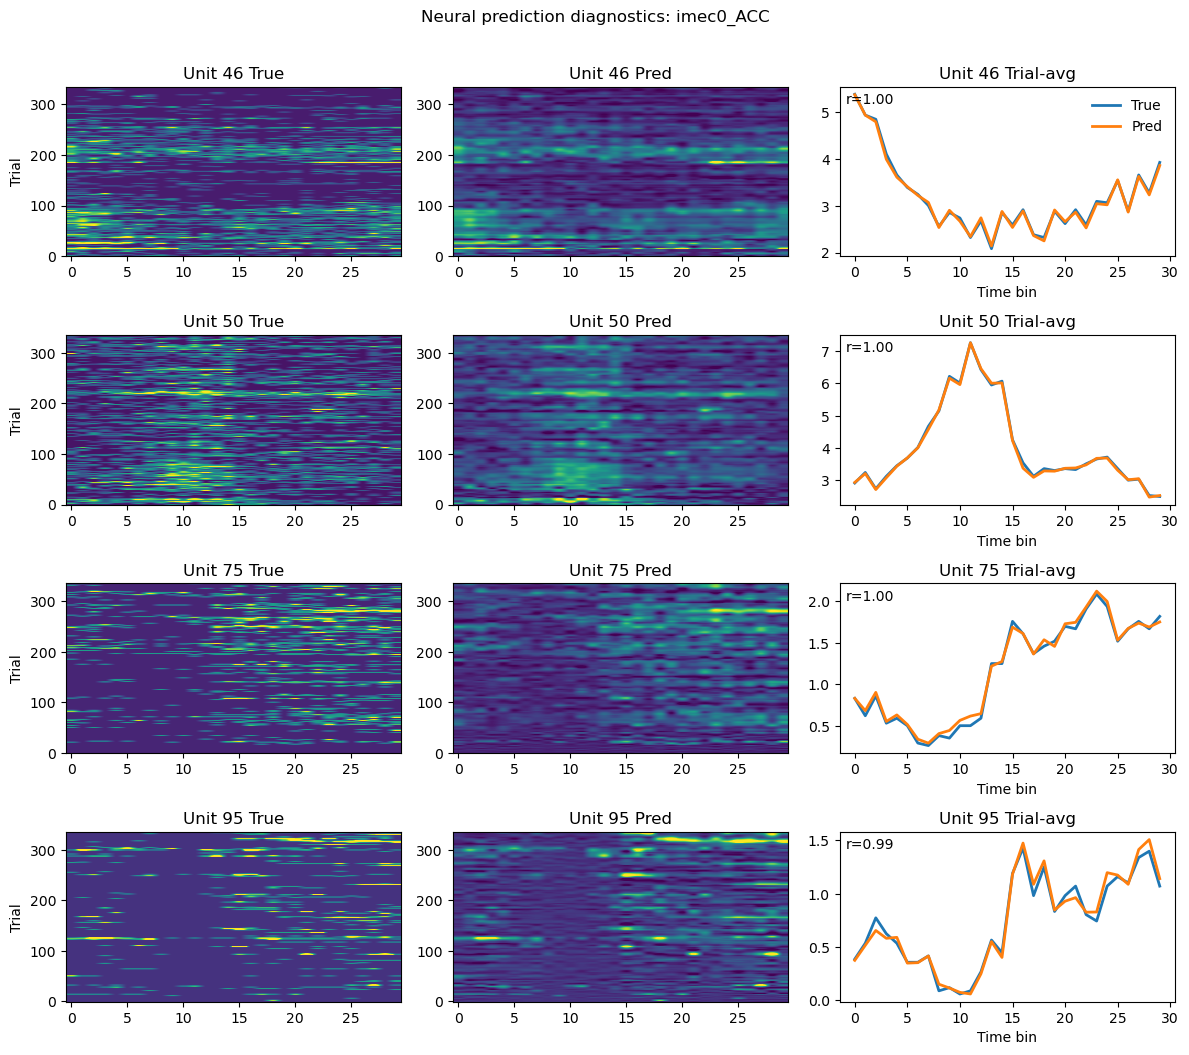

In [32]:
# visualize_neural_predictions – imported from rnn_utils

visualize_neural_predictions(
    neural_model,
    X_neural_torch,
    Y_neural_torch,
    neural_meta,
    TARGET_KEY,
    n_units_to_plot=4,
    random_seed=1,
)